# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

In [36]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *
import torch
from torch.utils.data import DataLoader, random_split
import time

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Datasets 

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

## Modelo

- falar sobre o modelo escolhido: Unet Binaria e D dimensional

## Métricas

- mostrar como as metricas estao sendo calculadas

A regra de matching utilizada foi a guloso por IoU.

## Parte 0 - Teste Unitário

In [37]:
# Created the synthetic images 
synthetic_train = build_dataset("synthetic", num_samples=536, img_size=128)
synthetic_val = build_dataset("synthetic", num_samples=134, img_size=128)
# synthetic_test = build_dataset("synthetic", num_samples=65, img_size=128)

# Create data loaders
synthetic_train_loader = DataLoader(synthetic_train, batch_size=8, shuffle=True)
synthetic_val_loader = DataLoader(synthetic_val, batch_size=8, shuffle=False)
# synthetic_test_loader = DataLoader(synthetic_test, batch_size=8, shuffle=False)

# Train and evaluate the model
synthetic_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
start = time.time()
train_model(synthetic_model, synthetic_train_loader, device, part=1, num_epochs=5)
print(f"Training time: {(time.time() - start) / 60:.2f} minutes")


Epoch 1/5 | Loss: 0.1488 | IoU: 0.9058 | Dice: 0.9506
Epoch 2/5 | Loss: 0.0321 | IoU: 0.9804 | Dice: 0.9901
Epoch 3/5 | Loss: 0.0169 | IoU: 0.9904 | Dice: 0.9952
Epoch 4/5 | Loss: 0.0088 | IoU: 0.9960 | Dice: 0.9980
Epoch 5/5 | Loss: 0.0063 | IoU: 0.9972 | Dice: 0.9986
Training time: 2.54 minutes


Média global mAP: 0.0972
Média global Erro Absoluto de Contagem: 10.3134


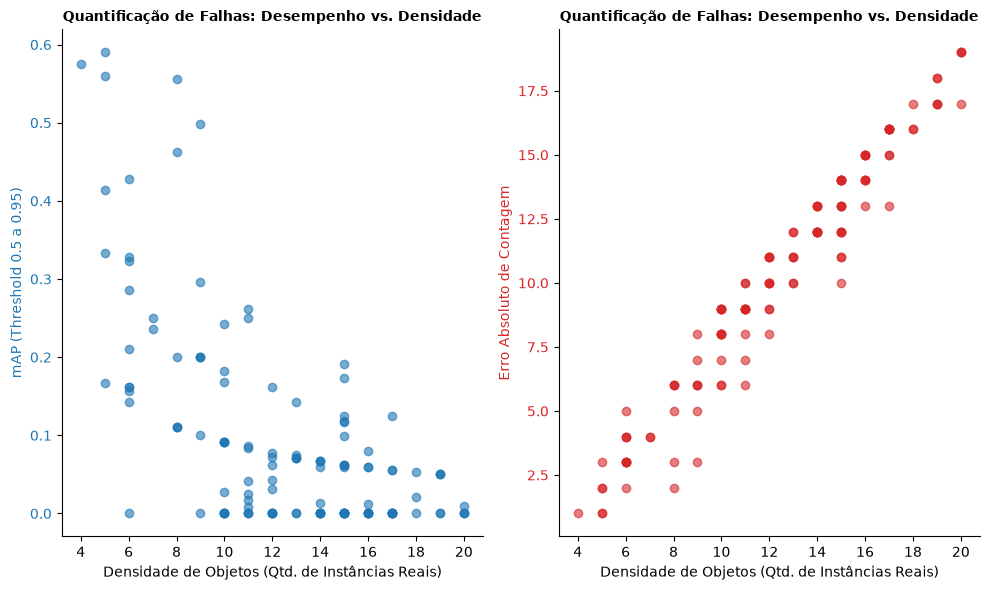

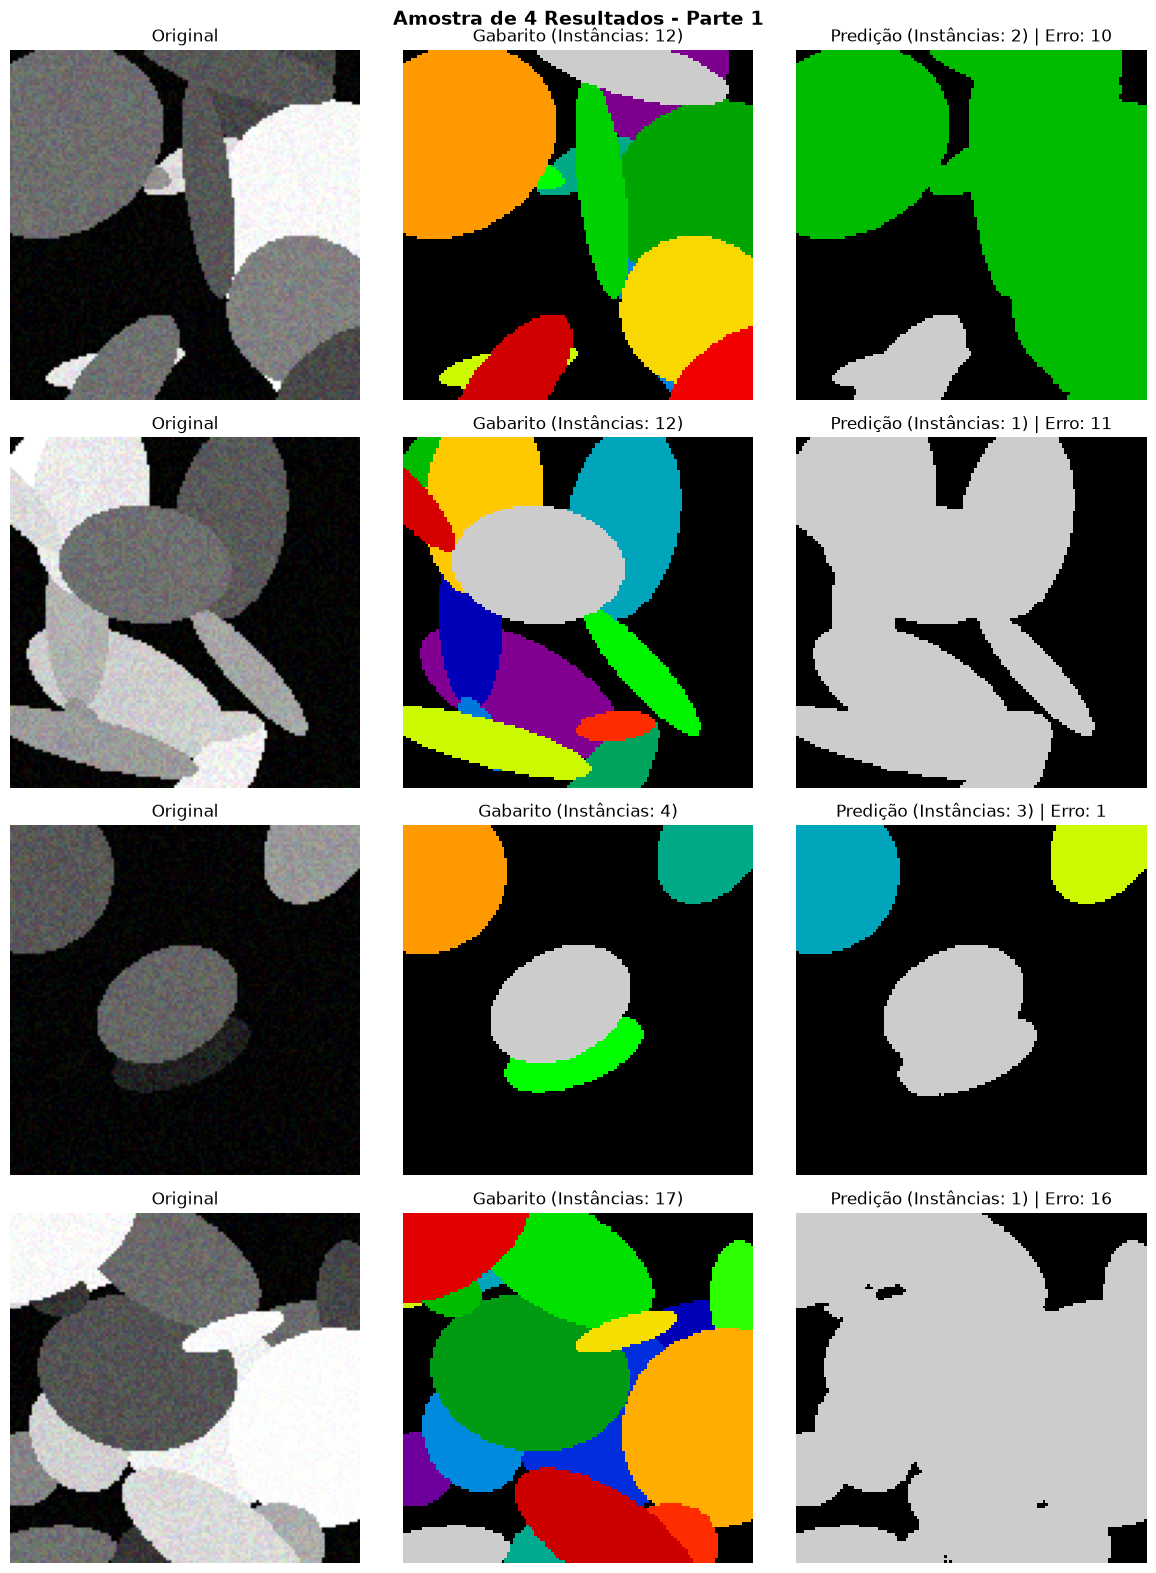

In [38]:
synthetic_mAP, synthetic_count_errors, synthetic_densities, synthetic_samples = evaluate(synthetic_model, synthetic_val_loader, device, part =1)
plot_metrics(synthetic_mAP, synthetic_count_errors, synthetic_densities)
plot_samples(synthetic_samples, part=1)

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

## Parte 1

In [41]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./../data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./../data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetBinary()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, part=1, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Epoch 1/10 | Loss: 0.2950 | IoU: 0.0084 | Dice: 0.0167
Epoch 2/10 | Loss: 0.1652 | IoU: 0.5305 | Dice: 0.6933
Epoch 3/10 | Loss: 0.1333 | IoU: 0.6584 | Dice: 0.7940
Epoch 4/10 | Loss: 0.1148 | IoU: 0.7065 | Dice: 0.8280
Epoch 5/10 | Loss: 0.1007 | IoU: 0.7386 | Dice: 0.8497
Epoch 6/10 | Loss: 0.1002 | IoU: 0.7421 | Dice: 0.8519
Epoch 7/10 | Loss: 0.0894 | IoU: 0.7682 | Dice: 0.8689
Epoch 8/10 | Loss: 0.0926 | IoU: 0.7622 | Dice: 0.8651
Epoch 9/10 | Loss: 0.0915 | IoU: 0.7617 | Dice: 0.8647
Epoch 10/10 | Loss: 0.0911 | IoU: 0.7655 | Dice: 0.8672


Média global mAP: 0.3693
Média global Erro Absoluto de Contagem: 18.3881


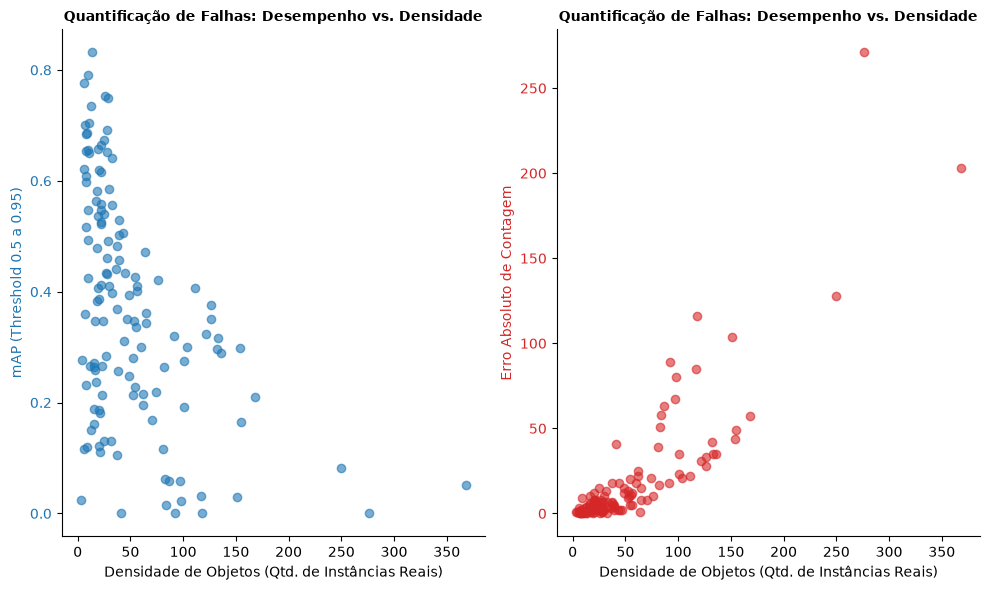

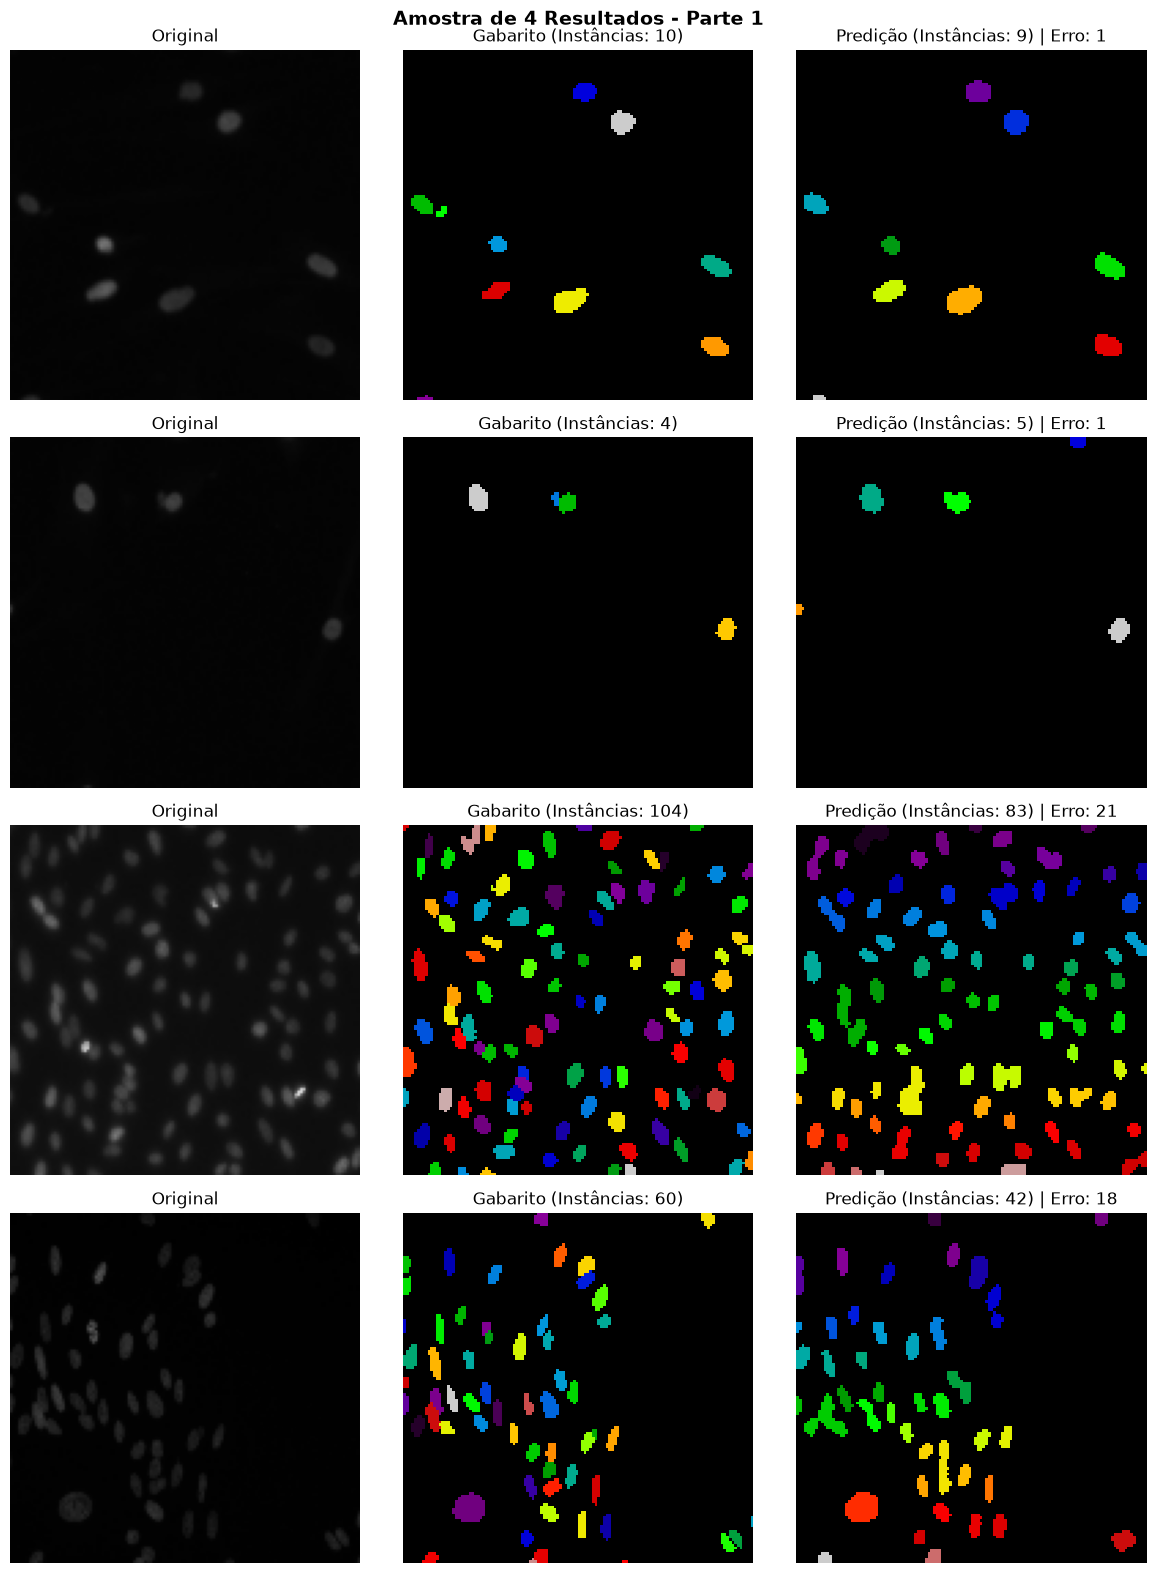

In [43]:
real_mAP, real_count_errors, real_densities, real_samples = evaluate(real_model, real_val_loader, device, part =1)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=1)

Parte 2 - Trilha B

In [44]:
# Extracted and formatted the images 
real_train_val = build_dataset("real", root_dir="./../data/stage1_train", img_size=128)
real_train, real_val = random_split(real_train_val, [int(0.8 * len(real_train_val)), int(0.2 * len(real_train_val))])
real_test = build_dataset("real", root_dir="./../data/stage1_test", img_size=128)
print(f"Real Train: {len(real_train)}, Real Val: {len(real_val)}, Real Test: {len(real_test)}")

# Create data loaders
real_train_loader = DataLoader(real_train, batch_size=8, shuffle=True)
real_val_loader = DataLoader(real_val, batch_size=8, shuffle=False)
real_test_loader = DataLoader(real_test, batch_size=8, shuffle=False)

# Train and evaluate the model
real_model = UNetDDimensional(D=2)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(real_model, real_train_loader, device, part=2, num_epochs=10)


Real Train: 536, Real Val: 134, Real Test: 65
Epoch 1/10 | Loss: 10.4725 | IoU: 0.0349 | Dice: 0.0674
Epoch 2/10 | Loss: 4.9209 | IoU: 0.0000 | Dice: 0.0001
Epoch 3/10 | Loss: 4.3817 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 4.4114 | IoU: 0.0001 | Dice: 0.0002
Epoch 5/10 | Loss: 4.1610 | IoU: 0.0030 | Dice: 0.0060
Epoch 6/10 | Loss: 4.0032 | IoU: 0.0489 | Dice: 0.0932
Epoch 7/10 | Loss: 3.9205 | IoU: 0.3930 | Dice: 0.5643
Epoch 8/10 | Loss: 3.7639 | IoU: 0.5851 | Dice: 0.7383
Epoch 9/10 | Loss: 3.6891 | IoU: 0.6366 | Dice: 0.7779
Epoch 10/10 | Loss: 3.6754 | IoU: 0.6563 | Dice: 0.7925


Média global mAP: 0.0867
Média global Erro Absoluto de Contagem: 38.1418


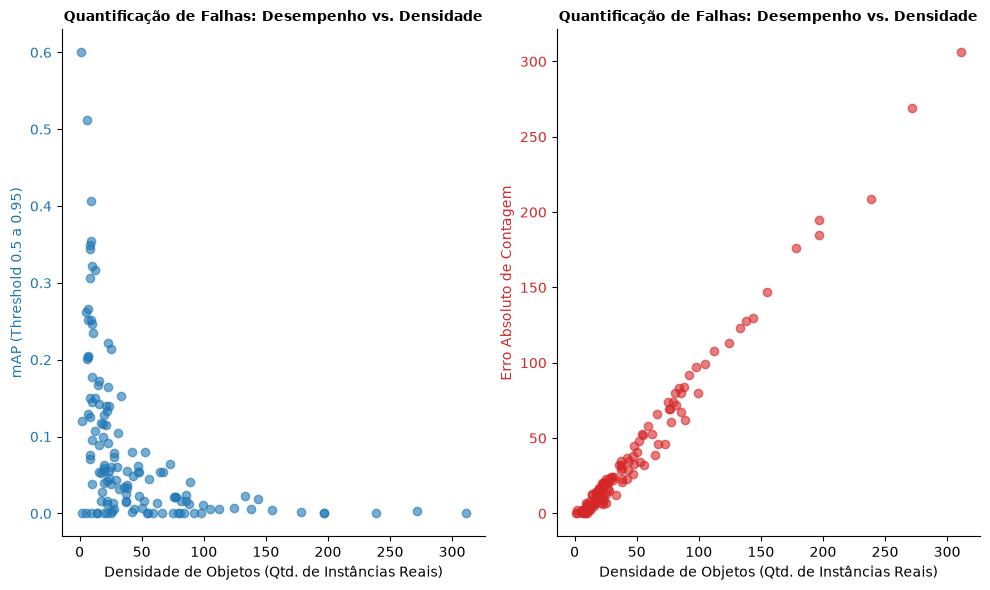

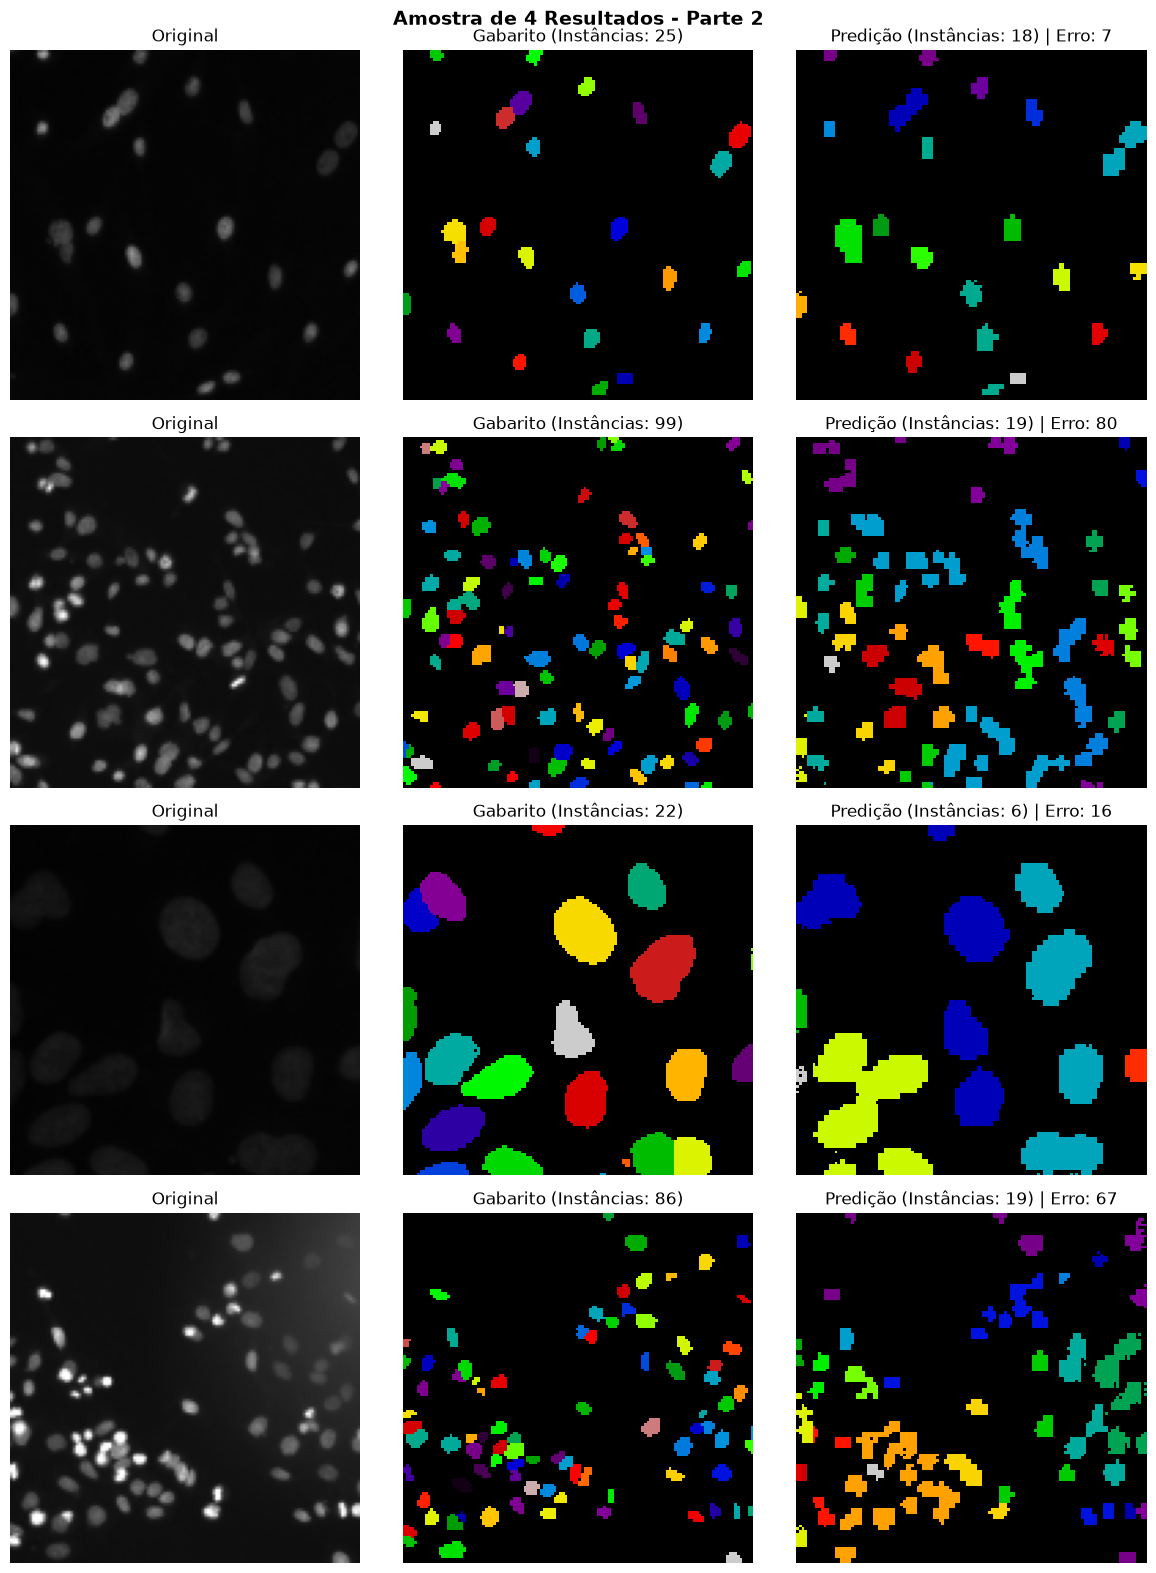

In [47]:
real_mAP, real_count_errors, real_densities, real_samples = evaluate(real_model, real_val_loader, device, part =2)
plot_metrics(real_mAP, real_count_errors, real_densities)
plot_samples(real_samples, part=2)

## Part 3

Eixos escolhidos 1 e 3

In [ ]:
mean_map_1, std_map_1 = ablation(real_train_loader, real_val_loader, device, axis=1)
mean_map_3, std_map_3 = ablation(real_train_loader, real_val_loader, device, axis=3)